In [1]:
import os
import random
import shutil
import tensorflow as tf
import numpy as np
import cv2
import pathlib
from PIL import Image
import matplotlib.pyplot as plt
import mlflow
import dagshub
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

### Counting the number of images present for each label

In [3]:
parent_folder = "Datasets/10_Garbage_Class"
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')

data_dir = pathlib.Path(parent_folder)

for folder_name in os.listdir(parent_folder):
    img_count = len(list(data_dir.glob(f'{folder_name}/*')))
    print(f'{folder_name}: {img_count} images')

battery: 756 images
biological: 699 images
cardboard: 1411 images
clothes: 1892 images
glass: 1736 images
metal: 930 images
paper: 1336 images
plastic: 1597 images
shoes: 1449 images
trash: 453 images


# Train, Validation and Test Splitting

In [4]:
"""def split_dataset(parent_folder):

    # percentages
    train_ratio = 0.7
    val_ratio = 0.15
    test_ratio = 0.15

    # get base folder (Datasets/)
    base_folder = os.path.dirname(parent_folder)

    train_path = os.path.join(base_folder, "Train")
    val_path = os.path.join(base_folder, "Val")
    test_path = os.path.join(base_folder, "Test")

    # create main folders
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)

    # loop through each class
    for label in os.listdir(parent_folder):

        label_path = os.path.join(parent_folder, label)

        if not os.path.isdir(label_path):
            continue

        print("Processing:", label)

        images = os.listdir(label_path)

        # remove hidden files if any
        images = [img for img in images if not img.startswith('.')]

        random.shuffle(images)

        total = len(images)

        # calculate split counts
        train_count = int(total * train_ratio)
        val_count = int(total * val_ratio)

        # split images
        train_images = images[:train_count]
        val_images = images[train_count:train_count + val_count]
        test_images = images[train_count + val_count:]

        # create label folders
        train_label = os.path.join(train_path, label)
        val_label = os.path.join(val_path, label)
        test_label = os.path.join(test_path, label)

        os.makedirs(train_label, exist_ok=True)
        os.makedirs(val_label, exist_ok=True)
        os.makedirs(test_label, exist_ok=True)

        # copy files
        for img in train_images:
            shutil.copy(os.path.join(label_path, img), os.path.join(train_label, img))

        for img in val_images:
            shutil.copy(os.path.join(label_path, img), os.path.join(val_label, img))

        for img in test_images:
            shutil.copy(os.path.join(label_path, img), os.path.join(test_label, img))

        print(f"{label} → Total:{total} | Train:{len(train_images)}, Val:{len(val_images)}, Test:{len(test_images)}")

    print("\nDone!")"""

'def split_dataset(parent_folder):\n\n    # percentages\n    train_ratio = 0.7\n    val_ratio = 0.15\n    test_ratio = 0.15\n\n    # get base folder (Datasets/)\n    base_folder = os.path.dirname(parent_folder)\n\n    train_path = os.path.join(base_folder, "Train")\n    val_path = os.path.join(base_folder, "Val")\n    test_path = os.path.join(base_folder, "Test")\n\n    # create main folders\n    os.makedirs(train_path, exist_ok=True)\n    os.makedirs(val_path, exist_ok=True)\n    os.makedirs(test_path, exist_ok=True)\n\n    # loop through each class\n    for label in os.listdir(parent_folder):\n\n        label_path = os.path.join(parent_folder, label)\n\n        if not os.path.isdir(label_path):\n            continue\n\n        print("Processing:", label)\n\n        images = os.listdir(label_path)\n\n        # remove hidden files if any\n        images = [img for img in images if not img.startswith(\'.\')]\n\n        random.shuffle(images)\n\n        total = len(images)\n\n        # c

In [5]:
"""parent_folder = "Datasets/10_Garbage_Class"
split_dataset(parent_folder)"""

'parent_folder = "Datasets/10_Garbage_Class"\nsplit_dataset(parent_folder)'

# Data Augmentation on Train Dataset

1. Rotation and flipping of images.
2. Adjusting brightness of images.
3. Introducing color jitter.
4. Gaussian noise
5. Salt and pepper noise


In [6]:
train_path = 'Datasets/Train'
data_dir = pathlib.Path(train_path)

for folder_name in os.listdir(train_path):
    img_count = len(list(data_dir.glob(f'{folder_name}/*')))
    print(f'{folder_name}: {img_count} images')

total_image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"Total Training Images: {total_image_count}")

battery: 529 images
biological: 489 images
cardboard: 987 images
clothes: 1324 images
glass: 1215 images
metal: 651 images
paper: 935 images
plastic: 1117 images
shoes: 1014 images
trash: 317 images
Total Training Images: 8577


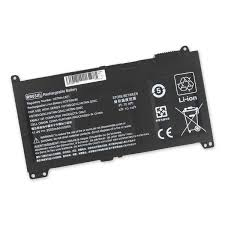

In [7]:
battery = list(data_dir.glob('battery/*'))
Image.open(str(battery[0]))

In [8]:
object_image_dict = {}

for folder_name in os.listdir(train_path):
    object_image_dict[folder_name] = list(data_dir.glob(f"{folder_name}/*"))

object_image_dict['battery']

[WindowsPath('Datasets/Train/battery/battery_1.jpg'),
 WindowsPath('Datasets/Train/battery/battery_10.jpg'),
 WindowsPath('Datasets/Train/battery/battery_101.jpg'),
 WindowsPath('Datasets/Train/battery/battery_102.jpg'),
 WindowsPath('Datasets/Train/battery/battery_103.jpg'),
 WindowsPath('Datasets/Train/battery/battery_104.jpg'),
 WindowsPath('Datasets/Train/battery/battery_105.jpg'),
 WindowsPath('Datasets/Train/battery/battery_109.jpg'),
 WindowsPath('Datasets/Train/battery/battery_11.jpg'),
 WindowsPath('Datasets/Train/battery/battery_110.jpg'),
 WindowsPath('Datasets/Train/battery/battery_111.jpg'),
 WindowsPath('Datasets/Train/battery/battery_112.jpg'),
 WindowsPath('Datasets/Train/battery/battery_115.jpg'),
 WindowsPath('Datasets/Train/battery/battery_117.jpg'),
 WindowsPath('Datasets/Train/battery/battery_118.jpg'),
 WindowsPath('Datasets/Train/battery/battery_119.jpg'),
 WindowsPath('Datasets/Train/battery/battery_12.jpg'),
 WindowsPath('Datasets/Train/battery/battery_120.jpg'

In [9]:
object_labels_dict = {}
label = 0
for folder_name in os.listdir(train_path):
    object_labels_dict[folder_name] = label
    label += 1

In [10]:
object_labels_dict

{'battery': 0,
 'biological': 1,
 'cardboard': 2,
 'clothes': 3,
 'glass': 4,
 'metal': 5,
 'paper': 6,
 'plastic': 7,
 'shoes': 8,
 'trash': 9}

In [11]:
img = cv2.imread(object_image_dict['battery'][3])
img.shape

(126, 400, 3)

In [12]:
cv2.resize(img, (256, 256)).shape

(256, 256, 3)

### Resize Images

In [13]:
X, y = [], []

for object_name, images in object_image_dict.items():
    for image in images:
        img = cv2.imread(image)
        resized_img = cv2.resize(img, (256, 256))
        X.append(resized_img)
        y.append(object_labels_dict[object_name])

In [14]:
X = np.array(X)
y = np.array(y)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

### Scaling the images

In [16]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

### Model Training and Tracking in Dagshub

In [19]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [17]:
num_classes = len(os.listdir(train_path))

model = Sequential([
    Conv2D(16, 3, padding='same', activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
202/202 [==============================] - 18s 42ms/step - loss: 1.9367 - accuracy: 0.3219
Epoch 2/30
202/202 [==============================] - 8s 40ms/step - loss: 1.4425 - accuracy: 0.5103
Epoch 3/30
202/202 [==============================] - 8s 40ms/step - loss: 1.1253 - accuracy: 0.6213
Epoch 4/30
202/202 [==============================] - 8s 39ms/step - loss: 0.8182 - accuracy: 0.7259
Epoch 5/30
202/202 [==============================] - 8s 39ms/step - loss: 0.5612 - accuracy: 0.8100
Epoch 6/30
202/202 [==============================] - 8s 39ms/step - loss: 0.3014 - accuracy: 0.8999
Epoch 7/30
202/202 [==============================] - 8s 39ms/step - loss: 0.2872 - accuracy: 0.9089
Epoch 8/30
202/202 [==============================] - 8s 39ms/step - loss: 0.1493 - accuracy: 0.9566
Epoch 9/30
202/202 [==============================] - 8s 40ms/step - loss: 0.0856 - accuracy: 0.9767
Epoch 10/30
202/202 [==============================] - 8s 39ms/step - loss: 0.0939 - accur

In [20]:
model.evaluate(X_test_scaled, y_test)

68/68 [==============================] - 1s 16ms/step - loss: 4.9795 - accuracy: 0.5604


[4.9795331954956055, 0.5603729486465454]